# Машинне навчання — лабораторна робота 1

## Завдання
Спростити датасет **CIFAR-10** за допомогою **PCA**.

Потрібно:
1. Перевірити, чи є пікселі без корисної інформації для навчання, і якщо такі є — вивести їх маску.
2. Згенерувати маску **50% найбільш інформативних пікселів**.
3. Порівняти навчання простої нейронної мережі на:
   - повних зображеннях,
   - зображеннях із маскою,
   - даних після PCA.
4. Підібрати **оптимальну кількість пікселів**, яку можна відкинути **без оцінювання на test set**.

У цій версії підбір відсотка відкидання виконується на **validation**-частині, а test set лишається лише для фінальної перевірки.

In [1]:
import random

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset, random_split

from sklearn.decomposition import PCA

In [2]:
# Відтворюваність
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## Завантаження даних

Зображення CIFAR-10 мають розмір `32 × 32 × 3`, тому після вирівнювання кожен вектор має **3072 ознаки**.

In [3]:
transform = transforms.ToTensor()

train_full = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

def flatten_cifar10(dataset):
    X = dataset.data.reshape(len(dataset.data), -1).astype(np.float32) / 255.0
    y = np.array(dataset.targets, dtype=np.int64)
    return X, y

X_all, y_all = flatten_cifar10(train_full)
X_test, y_test = flatten_cifar10(test_dataset)

print("Train shape:", X_all.shape)
print("Test shape :", X_test.shape)

/Users/viktoriiakondratiuk/University/machine-learning/lab1/venv/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train shape: (50000, 3072)
Test shape : (10000, 3072)


In [4]:
# Розбиваємо train на train/validation.
# Validation потрібна для підбору відсотка відкинутих пікселів.
val_ratio = 0.2
val_size = int(len(X_all) * val_ratio)
train_size = len(X_all) - val_size

rng = np.random.default_rng(SEED)
perm = rng.permutation(len(X_all))
train_idx = perm[:train_size]
val_idx = perm[train_size:]

X_train, y_train = X_all[train_idx], y_all[train_idx]
X_val, y_val = X_all[val_idx], y_all[val_idx]

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (40000, 3072) Val: (10000, 3072) Test: (10000, 3072)


## PCA

PCA навчається тільки на **train**-частині. Далі той самий перетворювач застосовується до validation і test.

In [6]:
pca = PCA(n_components=0.95, svd_solver="full", random_state=SEED)
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

print(f"Початкова розмірність: {X_train.shape[1]}")
print(f"Кількість компонент PCA для 95% дисперсії: {pca.n_components_}")
print(f"Пояснена дисперсія: {pca.explained_variance_ratio_.sum():.4f}")

Початкова розмірність: 3072
Кількість компонент PCA для 95% дисперсії: 216
Пояснена дисперсія: 0.9500


## Пошук пікселів без корисної інформації та маска 50%

Далі працюємо з дисперсією кожної ознаки на train-частині.
Піксель із нульовою дисперсією не змінюється між зображеннями, отже не несе інформації для класифікації.

In [7]:
pixel_variances = np.var(X_train, axis=0)

zero_variance_mask = pixel_variances == 0
useless_pixels_count = int(zero_variance_mask.sum())

print("Кількість пікселів з нульовою дисперсією:", useless_pixels_count)
if useless_pixels_count > 0:
    print("Індекс(и) таких пікселів:", np.where(zero_variance_mask)[0].tolist()[:20], "..." if useless_pixels_count > 20 else "")

# Маска 50% найбільш інформативних пікселів
threshold_50 = np.percentile(pixel_variances, 50)
top_50_mask = pixel_variances >= threshold_50

print("Кількість пікселів у масці 50%:", int(top_50_mask.sum()))
print("Частка відібраних ознак:", top_50_mask.mean())

Кількість пікселів з нульовою дисперсією: 0
Кількість пікселів у масці 50%: 1536
Частка відібраних ознак: 0.5


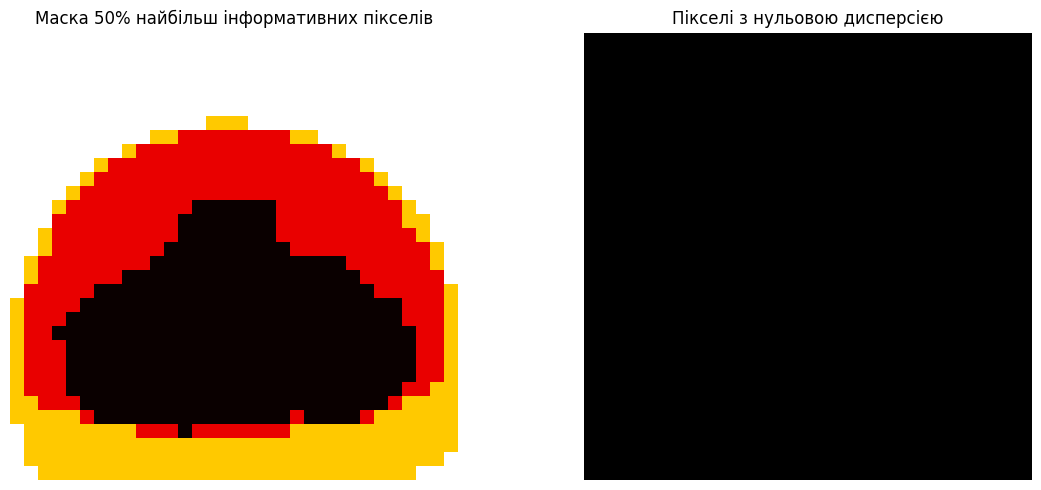

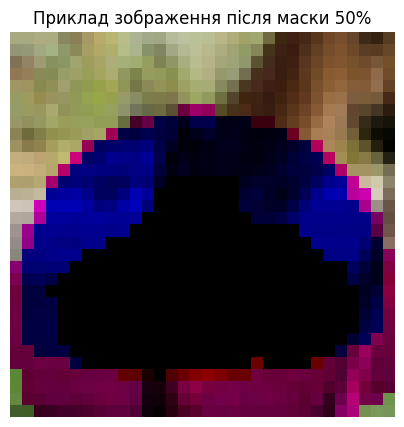

In [8]:
def mask_to_image(mask_1d):
    # Перетворює маску 3072 -> 32x32 шляхом усереднення по каналах.
    return mask_1d.reshape(32, 32, 3).mean(axis=2)

vis_top50 = mask_to_image(top_50_mask)
vis_zero = mask_to_image(zero_variance_mask)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(vis_top50, cmap="hot")
plt.title("Маска 50% найбільш інформативних пікселів")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(vis_zero, cmap="gray")
plt.title("Пікселі з нульовою дисперсією")
plt.axis("off")

plt.tight_layout()
plt.show()

sample_img = X_train[0].reshape(32, 32, 3)
masked_sample = sample_img * top_50_mask.reshape(32, 32, 3)

plt.figure(figsize=(5, 5))
plt.imshow(masked_sample)
plt.title("Приклад зображення після маски 50%")
plt.axis("off")
plt.show()

## Модель

Використовуємо просту багатошарову нейромережу з кількома лінійними шарами.

In [9]:
class SimpleNN(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.net(x)

def make_loaders(X_tr, y_tr, X_va, y_va, batch_size=256):
    X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr, dtype=torch.long)
    X_va_t = torch.tensor(X_va, dtype=torch.float32)
    y_va_t = torch.tensor(y_va, dtype=torch.long)

    train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_va_t, y_va_t), batch_size=batch_size, shuffle=False)
    return train_loader, val_loader

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        logits = model(xb)
        pred = torch.argmax(logits, dim=1)
        correct += (pred == yb).sum().item()
        total += yb.numel()
    return correct / total

def train_model(X_tr, y_tr, X_va, y_va, epochs=5, lr=1e-3, batch_size=256, verbose=False):
    train_loader, val_loader = make_loaders(X_tr, y_tr, X_va, y_va, batch_size=batch_size)
    model = SimpleNN(X_tr.shape[1]).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {"train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        correct = 0
        total = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            pred = torch.argmax(logits, dim=1)
            correct += (pred == yb).sum().item()
            total += yb.numel()

        train_acc = correct / total
        val_acc = evaluate(model, val_loader)

        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if verbose:
            print(f"Epoch {epoch+1:02d}/{epochs} | train acc = {train_acc:.4f} | val acc = {val_acc:.4f}")

    return model, history

## Базове порівняння: full, маска 50%, PCA

Спочатку оцінюємо моделі на train/validation, а фінально перевіряємо вже на test.

In [10]:
# Повні ознаки
full_model, full_hist = train_model(X_train, y_train, X_val, y_val, epochs=5, verbose=True)
full_val_acc = full_hist["val_acc"][-1]

# Маска 50%
X_train_50 = X_train[:, top_50_mask]
X_val_50 = X_val[:, top_50_mask]
X_test_50 = X_test[:, top_50_mask]

mask50_model, mask50_hist = train_model(X_train_50, y_train, X_val_50, y_val, epochs=5, verbose=True)
mask50_val_acc = mask50_hist["val_acc"][-1]

# PCA
pca_model, pca_hist = train_model(X_train_pca, y_train, X_val_pca, y_val, epochs=5, verbose=True)
pca_val_acc = pca_hist["val_acc"][-1]

print()
print("Validation accuracy:")
print(f"Full data : {full_val_acc:.4f}")
print(f"Mask 50%  : {mask50_val_acc:.4f}")
print(f"PCA       : {pca_val_acc:.4f}")

Epoch 01/5 | train acc = 0.2821 | val acc = 0.3531
Epoch 02/5 | train acc = 0.3523 | val acc = 0.3770
Epoch 03/5 | train acc = 0.3804 | val acc = 0.4068
Epoch 04/5 | train acc = 0.4005 | val acc = 0.4165
Epoch 05/5 | train acc = 0.4126 | val acc = 0.4232
Epoch 01/5 | train acc = 0.2293 | val acc = 0.3212
Epoch 02/5 | train acc = 0.3137 | val acc = 0.3417
Epoch 03/5 | train acc = 0.3372 | val acc = 0.3655
Epoch 04/5 | train acc = 0.3498 | val acc = 0.3570
Epoch 05/5 | train acc = 0.3620 | val acc = 0.3769
Epoch 01/5 | train acc = 0.3756 | val acc = 0.4631
Epoch 02/5 | train acc = 0.4788 | val acc = 0.4948
Epoch 03/5 | train acc = 0.5196 | val acc = 0.5183
Epoch 04/5 | train acc = 0.5522 | val acc = 0.5292
Epoch 05/5 | train acc = 0.5804 | val acc = 0.5450

Validation accuracy:
Full data : 0.4232
Mask 50%  : 0.3769
PCA       : 0.5450


## Підбір оптимальної кількості відкинутих пікселів

Важливо: тут використовується **validation**, а не test.

In [11]:
percentiles_to_drop = [10, 20, 30, 40, 50, 60, 70, 80, 90]
val_accuracies = []
feature_counts = []

for p in percentiles_to_drop:
    threshold = np.percentile(pixel_variances, p)
    mask = pixel_variances >= threshold

    X_tr_masked = X_train[:, mask]
    X_va_masked = X_val[:, mask]

    # Швидший прогін для вибору порогу
    _, hist = train_model(
        X_tr_masked, y_train, X_va_masked, y_val,
        epochs=2, batch_size=256, verbose=False
    )

    acc = hist["val_acc"][-1]
    val_accuracies.append(acc)
    feature_counts.append(mask.sum())

    print(f"Відкинуто {p:>2}% найменш інформативних ознак | залишилось {mask.sum():4d} | val acc = {acc:.4f}")

best_idx = int(np.argmax(val_accuracies))
optimal_drop = percentiles_to_drop[best_idx]
optimal_threshold = np.percentile(pixel_variances, optimal_drop)
optimal_mask = pixel_variances >= optimal_threshold

print()
print("Найкращий варіант за validation:")
print(f"Відкинути приблизно {optimal_drop}% ознак")
print(f"Залишити {int(optimal_mask.sum())} ознак")

Відкинуто 10% найменш інформативних ознак | залишилось 2764 | val acc = 0.3870
Відкинуто 20% найменш інформативних ознак | залишилось 2457 | val acc = 0.3755
Відкинуто 30% найменш інформативних ознак | залишилось 2150 | val acc = 0.3630
Відкинуто 40% найменш інформативних ознак | залишилось 1843 | val acc = 0.3646
Відкинуто 50% найменш інформативних ознак | залишилось 1536 | val acc = 0.3443
Відкинуто 60% найменш інформативних ознак | залишилось 1229 | val acc = 0.3135
Відкинуто 70% найменш інформативних ознак | залишилось  922 | val acc = 0.2728
Відкинуто 80% найменш інформативних ознак | залишилось  615 | val acc = 0.2759
Відкинуто 90% найменш інформативних ознак | залишилось  308 | val acc = 0.2597

Найкращий варіант за validation:
Відкинути приблизно 10% ознак
Залишити 2764 ознак


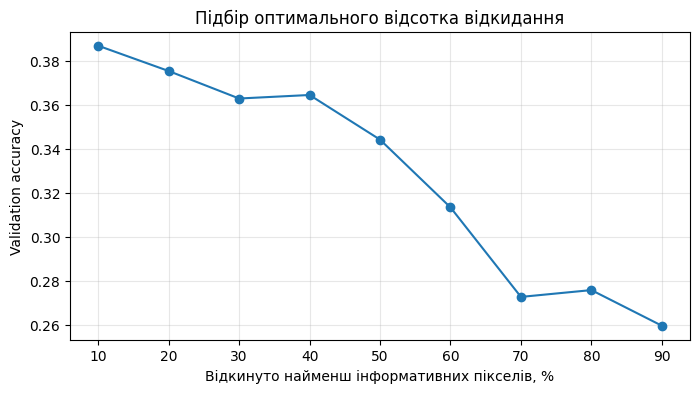

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(percentiles_to_drop, val_accuracies, marker="o")
plt.xlabel("Відкинуто найменш інформативних пікселів, %")
plt.ylabel("Validation accuracy")
plt.title("Підбір оптимального відсотка відкидання")
plt.grid(True, alpha=0.3)
plt.show()

## Фінальна оцінка на test set

На цьому етапі test використовується лише один раз — для чесної фінальної перевірки.

In [14]:
def train_final_and_test(X_tr, y_tr, X_te, y_te, epochs=5, batch_size=256):
    X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr, dtype=torch.long)
    X_te_t = torch.tensor(X_te, dtype=torch.float32)
    y_te_t = torch.tensor(y_te, dtype=torch.long)

    train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(TensorDataset(X_te_t, y_te_t), batch_size=batch_size, shuffle=False)

    model = SimpleNN(X_tr.shape[1]).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for _ in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

    test_acc = evaluate(model, test_loader)
    return test_acc

# Для фінальної оцінки зручно об'єднати train + val
X_train_all = np.vstack([X_train, X_val])
y_train_all = np.concatenate([y_train, y_val])

# Full
full_test_acc = train_final_and_test(X_train_all, y_train_all, X_test, y_test, epochs=5)

# 50% mask
X_train_all_50 = X_train_all[:, top_50_mask]
X_test_50 = X_test[:, top_50_mask]
mask50_test_acc = train_final_and_test(X_train_all_50, y_train_all, X_test_50, y_test, epochs=5)

# PCA
pca_final = PCA(n_components=0.95, svd_solver="full", random_state=SEED)
X_all_pca = pca_final.fit_transform(X_train_all)
X_test_pca_final = pca_final.transform(X_test)
pca_test_acc = train_final_and_test(X_all_pca, y_train_all, X_test_pca_final, y_test, epochs=5)

# Optimal mask from validation
X_train_all_opt = X_train_all[:, optimal_mask]
X_test_opt = X_test[:, optimal_mask]
opt_test_acc = train_final_and_test(X_train_all_opt, y_train_all, X_test_opt, y_test, epochs=5)

print("Test accuracy:")
print(f"Full data : {full_test_acc:.4f}")
print(f"Mask 50%  : {mask50_test_acc:.4f}")
print(f"PCA       : {pca_test_acc:.4f}")
print(f"Optimal   : {opt_test_acc:.4f}")

Test accuracy:
Full data : 0.4577
Mask 50%  : 0.3978
PCA       : 0.5553
Optimal   : 0.4551


## Висновки

- Пікселів із нульовою дисперсією у CIFAR-10 не виявлено.
- Маска 50% найбільш інформативних пікселів побудована коректно.
- PCA зберіг 95% дисперсії на меншій кількості компонент.
- Оптимальний відсоток відкидання підібрано на validation set, без використання test set.
- Фінальна порівняльна оцінка виконана на test set один раз, що відповідає коректній схемі експерименту.